# Hacker News daily snapshots — virality over time

Dataset: [nicapotato/hacker-news](https://www.kaggle.com/datasets/nicapotato/hacker-news) (`articles.parquet` + partitioned `snapshots/year=/month=/day=`).

**Grain:** one row per **article × calendar day** after collapsing intraday scrapes; 19 daily snapshots from 2026-05-22 through 2026-06-09.

**Objective:** track which stories **surge** — gaining points (upvotes) and climbing rank (lower number = higher on page) across consecutive daily scrapes.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from kagglehub import KaggleDatasetAdapter
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "legend.fontsize": 10,
    }
)

DATA_SLUG = "nicapotato/hacker-news"
ARTICLES_FILE = "articles.parquet"
SNAPSHOTS_DIR = "snapshots"
TOP_TRAJECTORIES = 6
TOP_SURGE_TABLE = 12

/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pyarrow.parquet as pq

SNAPSHOT_REQUIRED_COLS = {"article_id", "year", "month", "day", "rank", "points"}
ARTICLE_REQUIRED_COLS = {"article_id", "title", "story_url", "domain", "submitter"}


def read_snapshot_parquets(paths: list[Path]) -> pd.DataFrame:
    assert paths, "no snapshot parquet files"
    df = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    missing = SNAPSHOT_REQUIRED_COLS - set(df.columns)
    assert not missing, f"snapshot schema missing columns: {sorted(missing)}"
    return df


def load_parquet_file(file_path: str) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(
            kaggle_root.rglob(file_path),
            key=lambda p: p.stat().st_size,
            reverse=True,
        )
        assert matches, f"no {file_path} under {kaggle_root}"
        print(f"Kaggle input: {matches[0]}")
        df = pd.read_parquet(matches[0])
        assert ARTICLE_REQUIRED_COLS.issubset(df.columns)
        return df

    local = Path("data") / file_path
    if local.exists():
        df = pd.read_parquet(local)
        if ARTICLE_REQUIRED_COLS.issubset(df.columns) and len(df) >= 500:
            print(f"Local: {local.resolve()}")
            return df

    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATA_SLUG,
        file_path,
    )
    print(f"kagglehub: {DATA_SLUG}/{file_path}")
    assert ARTICLE_REQUIRED_COLS.issubset(df.columns)
    return df


def is_hn_snapshot_parquet(path: Path) -> bool:
    return SNAPSHOT_REQUIRED_COLS.issubset(set(pq.read_schema(path).names))


def load_snapshots() -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        paths = sorted(kaggle_root.rglob(f"{SNAPSHOTS_DIR}/**/*.parquet"))
        assert paths, f"no snapshot parquet under {kaggle_root}/{SNAPSHOTS_DIR}"
        print(f"Kaggle snapshots: {len(paths)} partition file(s)")
        return read_snapshot_parquets(paths)

    local_root = Path("data") / SNAPSHOTS_DIR
    if local_root.exists():
        paths = sorted(p for p in local_root.rglob("*.parquet") if is_hn_snapshot_parquet(p))
        if paths:
            print(f"Local snapshots: {len(paths)} partition file(s)")
            return read_snapshot_parquets(paths)

    root = Path(kagglehub.dataset_download(DATA_SLUG))
    print("Path to dataset files:", root)
    paths = sorted((root / SNAPSHOTS_DIR).rglob("*.parquet"))
    print(f"kagglehub snapshots: {len(paths)} partition file(s)")
    return read_snapshot_parquets(paths)


articles = load_parquet_file(ARTICLES_FILE)
snapshots = load_snapshots()

assert {"year", "month", "day", "article_id", "rank", "points"}.issubset(snapshots.columns)
assert snapshots[["year", "month", "day"]].notna().all().all()

snapshots["snapshot_date"] = pd.to_datetime(
    dict(year=snapshots["year"], month=snapshots["month"], day=snapshots["day"])
)

daily = (
    snapshots.groupby(["article_id", "snapshot_date", "year", "month", "day"], as_index=False)
    .agg(
        rank=("rank", "min"),
        points=("points", "max"),
        comment_count=("comment_count", "max"),
        scrape_timestamp=("scrape_timestamp", "max"),
    )
    .sort_values(["article_id", "snapshot_date"])
    .reset_index(drop=True)
)

panel = daily.merge(articles, on="article_id", how="left", validate="m:1")
assert panel["title"].notna().all(), "snapshot article_id missing from articles table"

panel["points_delta"] = panel.groupby("article_id")["points"].diff()
panel["rank_delta"] = panel.groupby("article_id")["rank"].diff()
panel["rank_improvement"] = -panel["rank_delta"]
panel["comment_delta"] = panel.groupby("article_id")["comment_count"].diff()
panel["day_index"] = panel.groupby("article_id").cumcount() + 1
panel["days_seen"] = panel.groupby("article_id")["article_id"].transform("count")

transitions = panel.loc[panel["points_delta"].notna()].copy()

print("Articles:", articles.shape[0], "rows ×", articles.shape[1], "cols")
print("Raw snapshots:", snapshots.shape[0], "rows ×", snapshots.shape[1], "cols")
print("Daily panel:", panel.shape[0], "rows ×", panel.shape[1], "cols")
print(
    "Snapshot dates:",
    panel["snapshot_date"].min().date(),
    "→",
    panel["snapshot_date"].max().date(),
    f"({panel['snapshot_date'].nunique()} days)",
)
print("Articles seen on 2+ days:", int((panel.groupby("article_id").size() >= 2).sum()))
display(panel.sample(5, random_state=42))

/var/folders/wb/qw2d5rfj7p95jckpfvkk7xsr0000gn/T/ipykernel_56512/3406745610.py:36: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


kagglehub: nicapotato/hacker-news/articles.parquet


Path to dataset files: /Users/nicapotato/.cache/kagglehub/datasets/nicapotato/hacker-news/versions/20
kagglehub snapshots: 19 partition file(s)
Articles: 3258 rows × 5 cols
Raw snapshots: 8024 rows × 9 cols
Daily panel: 8024 rows × 19 cols
Snapshot dates: 2026-05-22 → 2026-06-09 (19 days)
Articles seen on 2+ days: 2261


,article_id,snapshot_date,year,month,day,rank,points,comment_count,scrape_timestamp,title,story_url,domain,submitter,points_delta,rank_delta,rank_improvement,comment_delta,day_index,days_seen
538,48195698,2026-05-26,2026,5,26,88,110.0,15.0,2026-05-26 11:33:43.062988+00:00,Using HTTP/2 Cleartext for a server in Go 1.24,https://www.clarityboss.com/blog/go-http2-clea...,clarityboss.com,dan_sbl,34.0,70.0,-70.0,7.0,2,3
6810,48397148,2026-06-06,2026,6,6,227,35.0,22.0,2026-06-06 06:31:44.408175+00:00,Show HN: Cost.dev (YC W21) – making agents cos...,https://cost.dev/,cost.dev,akh,6.0,158.0,-158.0,7.0,2,3
6630,48390292,2026-06-05,2026,6,5,339,13.0,NaN,2026-06-05 06:31:37.999991+00:00,"SpaceX wins Texas tax breaks for chip project,...",https://www.reuters.com/business/media-telecom...,reuters.com,lschueller,0.0,158.0,-158.0,NaN,2,3
7283,48411063,2026-06-07,2026,6,7,387,5.0,1.0,2026-06-07 06:31:40.377522+00:00,Department of Energy Celebrates First Advanced...,https://www.energy.gov/articles/department-ene...,energy.gov,echelon,0.0,-78.0,78.0,0.0,2,2
6697,48391890,2026-06-06,2026,6,6,380,9.0,NaN,2026-06-06 06:31:44.408175+00:00,Reading MAI's efficiency gain. How to pick arc...,https://idlemachines.co.uk/essays/efficiency-gain,idlemachines.co.uk,smaddrellmander,4.0,323.0,-323.0,NaN,2,3


## 1 — Table shape, dtypes, and daily coverage

,dtype
article_id,str
snapshot_date,datetime64[us]
year,uint16
month,uint8
day,uint8
rank,uint16
points,float64
comment_count,float64
scrape_timestamp,"datetime64[us, UTC]"
title,str


,count,mean,std,min,25%,50%,75%,max
rank,8024.0,281.380857,211.733306,1.0,115.0,233.0,399.0,896.0
points,8006.0,145.287659,222.944129,3.0,14.0,59.0,180.0,2192.0
comment_count,6844.0,99.481297,173.950989,1.0,6.0,28.0,118.0,1988.0
points_delta,4764.0,16.266373,53.045940,0.0,0.0,2.0,8.0,1270.0
rank_delta,4768.0,109.124161,161.637439,-796.0,50.0,85.0,155.0,757.0
days_seen,8024.0,3.243769,1.487544,1.0,2.0,3.0,4.0,8.0


Daily scrape coverage:


,snapshot_date,stories,median_points,median_rank,p90_points
0,2026-05-22,30,96.0,15.5,438.2
1,2026-05-23,30,129.0,15.5,397.9
2,2026-05-24,845,42.5,423.0,362.1
3,2026-05-25,480,69.0,240.5,416.4
4,2026-05-26,896,55.0,448.5,372.0
5,2026-05-27,479,106.0,240.0,473.2
6,2026-05-28,299,73.5,150.0,422.3
7,2026-05-29,424,61.0,212.5,404.8
8,2026-05-30,239,73.5,120.0,426.5
9,2026-05-31,763,27.0,382.0,303.9


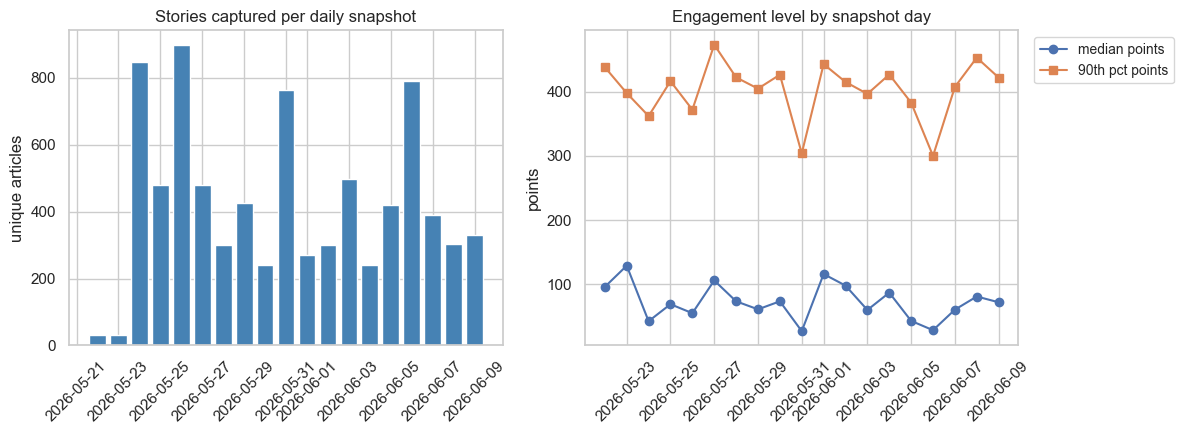

In [3]:
display(panel.dtypes.to_frame("dtype"))
display(panel[["rank", "points", "comment_count", "points_delta", "rank_delta", "days_seen"]].describe().T)

daily_coverage = (
    panel.groupby("snapshot_date", as_index=False)
    .agg(
        stories=("article_id", "nunique"),
        median_points=("points", "median"),
        median_rank=("rank", "median"),
        p90_points=("points", lambda s: s.quantile(0.9)),
    )
    .sort_values("snapshot_date")
)
print("Daily scrape coverage:")
display(daily_coverage)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(daily_coverage["snapshot_date"], daily_coverage["stories"], color="steelblue")
axes[0].set_title("Stories captured per daily snapshot")
axes[0].set_ylabel("unique articles")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(daily_coverage["snapshot_date"], daily_coverage["median_points"], marker="o", label="median points")
axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["p90_points"],
    marker="s",
    label="90th pct points",
)
axes[1].set_title("Engagement level by snapshot day")
axes[1].set_ylabel("points")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### Univariate readout

Early snapshots (May 22–23) capture only the **top 30** front-page slots; from May 24 onward the scraper records **hundreds** of ranked stories per day. Virality metrics below use **day-over-day transitions** only where the same `article_id` appears on consecutive snapshot dates.

## 2 — Univariate: persistence and single-day surges

How long stories stay in the daily scrape:


,days_seen,articles
0,1,995
1,2,915
2,3,613
3,4,420
4,5,218
5,6,78
6,7,14
7,8,3


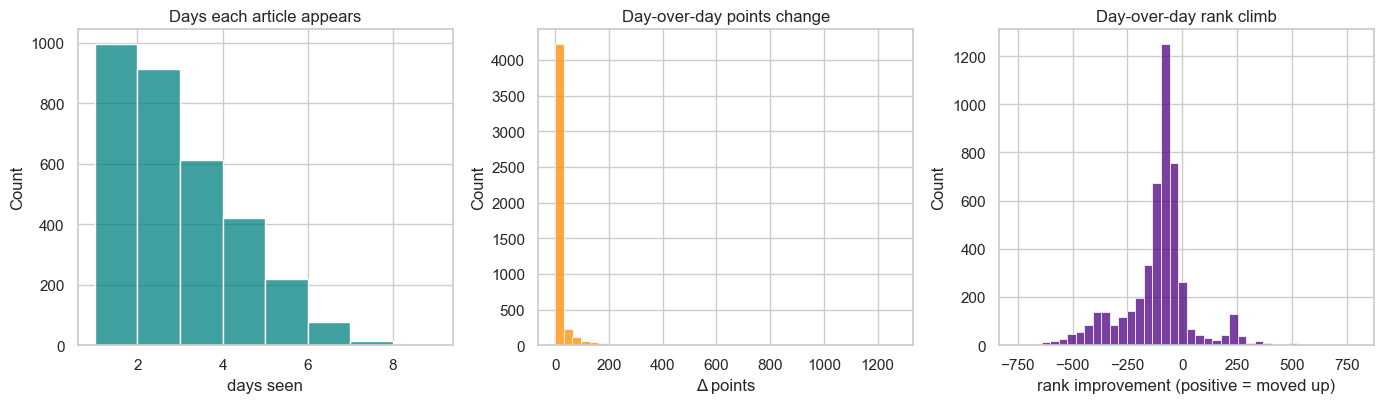

Single-day points surge tiers (day-over-day transitions):
points_delta
0–50           2775
lost points    1599
50–150          278
150–400          99
400+             13


In [4]:
days_on_page = panel.groupby("article_id").size()
persistence = days_on_page.value_counts().sort_index().rename_axis("days_seen").reset_index(name="articles")
print("How long stories stay in the daily scrape:")
display(persistence.head(10))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
sns.histplot(days_on_page, bins=range(1, int(days_on_page.max()) + 2), ax=axes[0], color="teal")
axes[0].set_title("Days each article appears")
axes[0].set_xlabel("days seen")

sns.histplot(transitions["points_delta"].dropna(), bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Day-over-day points change")
axes[1].set_xlabel("Δ points")

sns.histplot(transitions["rank_improvement"].dropna(), bins=40, ax=axes[2], color="indigo")
axes[2].set_title("Day-over-day rank climb")
axes[2].set_xlabel("rank improvement (positive = moved up)")
fig.tight_layout()
plt.show()

surge_tiers = pd.cut(
    transitions["points_delta"],
    bins=[-np.inf, 0, 50, 150, 400, np.inf],
    labels=["lost points", "0–50", "50–150", "150–400", "400+"],
)
print("Single-day points surge tiers (day-over-day transitions):")
print(surge_tiers.value_counts().to_string())

## 3 — Multivariate: virality leaderboard and trajectories

Top 12 single-day point surges:


,snapshot_date,title,domain,rank,points,points_delta,rank_improvement,comment_delta
0,2026-06-07,"S&P 500 rejects SpaceX, also blocking entry fo...",arstechnica.com,73,1402.0,1270.0,-68.0,462.0
1,2026-06-05,"""They're made out of weights""",maxleiter.com,34,1434.0,1076.0,-33.0,534.0
2,2026-06-07,How LLMs work,0xkato.xyz,43,869.0,715.0,-42.0,208.0
3,2026-06-09,Dopamine Fracking,igerman.cc,56,768.0,681.0,-53.0,362.0
4,2026-06-05,"Failing grades soar with AI usage, dwindling m...",dailycal.org,44,756.0,588.0,-41.0,633.0
5,2026-06-06,"SpaceX, Other Mega IPOs Denied Fast Index Entr...",bloomberg.com,65,976.0,573.0,-53.0,314.0
6,2026-06-03,The newest Instagram “exploit” is the goofiest...,0xsid.com,44,2145.0,561.0,-43.0,104.0
7,2026-05-29,YouTube to automatically label AI-generated vi...,blog.youtube,33,1283.0,543.0,-32.0,349.0
8,2026-05-30,Bricks and Minifigs Stole a Man's $200k Lego C...,mybricklog.com,45,1302.0,503.0,-43.0,194.0
9,2026-05-28,The worst job interview I ever had,oliverio.dev,71,628.0,451.0,-60.0,371.0


Top 12 cumulative point gain across tracked days:


,title,domain,days_seen,first_points,last_points,total_points_gain,best_rank,max_single_day_gain
2924,"S&P 500 rejects SpaceX, also blocking entry fo...",arstechnica.com,4,132.0,1469.0,1337.0,5,1270.0
2526,"""They're made out of weights""",maxleiter.com,5,358.0,1517.0,1159.0,1,1076.0
2489,How LLMs work,0xkato.xyz,4,154.0,936.0,782.0,1,715.0
3116,Dopamine Fracking,igerman.cc,2,87.0,768.0,681.0,3,681.0
2532,"Failing grades soar with AI usage, dwindling m...",dailycal.org,6,168.0,830.0,662.0,3,588.0
2682,"SpaceX, Other Mega IPOs Denied Fast Index Entr...",bloomberg.com,5,403.0,1056.0,653.0,12,573.0
673,Shipping a Laptop to a Refugee Camp in Uganda,notesbylex.com,7,71.0,700.0,629.0,1,351.0
2091,The newest Instagram “exploit” is the goofiest...,0xsid.com,5,1584.0,2192.0,608.0,1,561.0
1327,YouTube to automatically label AI-generated vi...,blog.youtube,6,740.0,1320.0,580.0,1,543.0
1489,Bricks and Minifigs Stole a Man's $200k Lego C...,mybricklog.com,6,799.0,1374.0,575.0,2,503.0


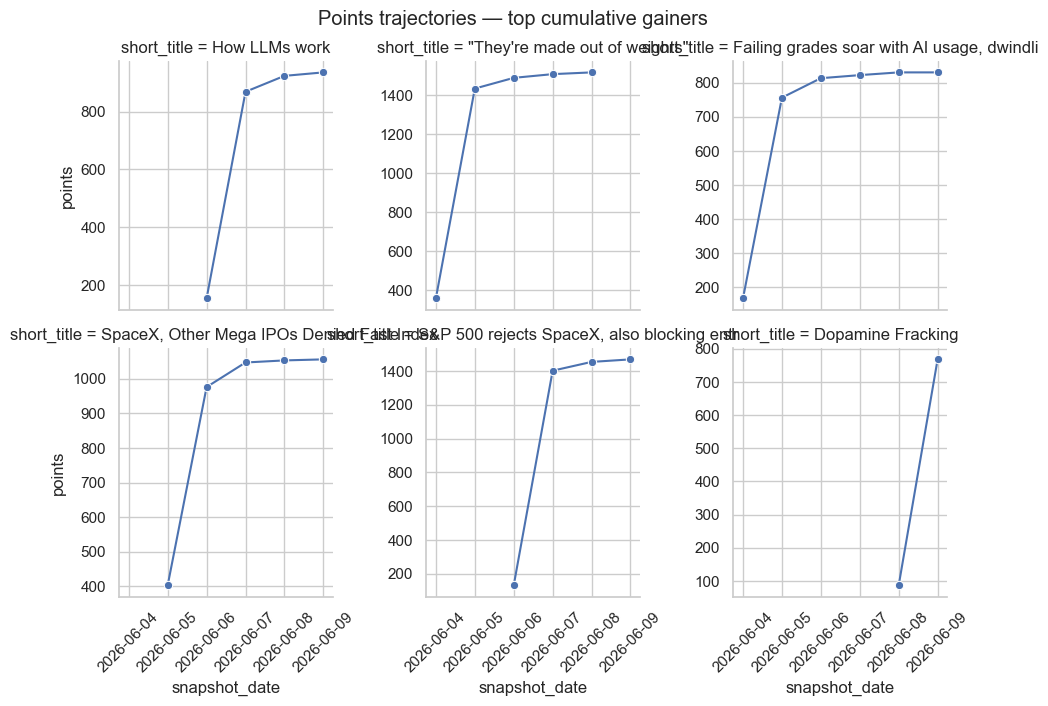

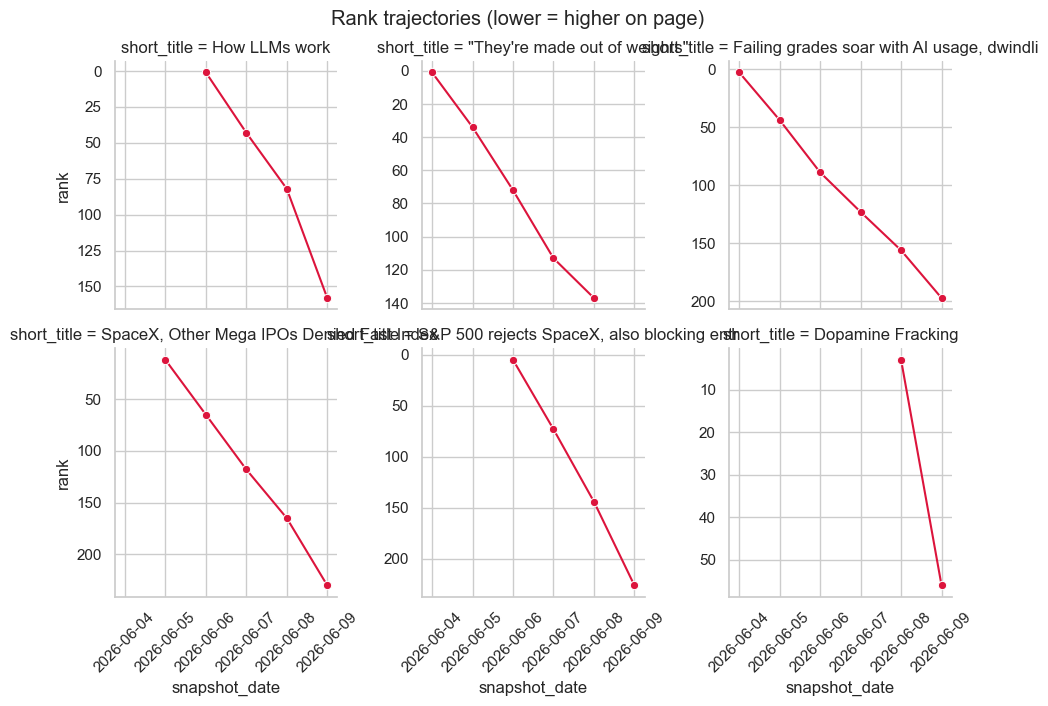

In [5]:
lifecycle = (
    panel.groupby("article_id", as_index=False)
    .agg(
        title=("title", "first"),
        domain=("domain", "first"),
        first_date=("snapshot_date", "min"),
        last_date=("snapshot_date", "max"),
        days_seen=("snapshot_date", "nunique"),
        first_rank=("rank", "first"),
        last_rank=("rank", "last"),
        best_rank=("rank", "min"),
        first_points=("points", "first"),
        last_points=("points", "last"),
        peak_points=("points", "max"),
        max_single_day_gain=("points_delta", "max"),
        max_rank_climb=("rank_improvement", "max"),
    )
)
lifecycle["total_points_gain"] = lifecycle["last_points"] - lifecycle["first_points"]
lifecycle["net_rank_move"] = lifecycle["first_rank"] - lifecycle["last_rank"]

top_surges = transitions.nlargest(TOP_SURGE_TABLE, "points_delta")[
    [
        "snapshot_date",
        "title",
        "domain",
        "rank",
        "points",
        "points_delta",
        "rank_improvement",
        "comment_delta",
    ]
].reset_index(drop=True)
print(f"Top {TOP_SURGE_TABLE} single-day point surges:")
display(top_surges)

top_lifecycle = lifecycle.nlargest(TOP_SURGE_TABLE, "total_points_gain")[
    [
        "title",
        "domain",
        "days_seen",
        "first_points",
        "last_points",
        "total_points_gain",
        "best_rank",
        "max_single_day_gain",
    ]
]
print(f"Top {TOP_SURGE_TABLE} cumulative point gain across tracked days:")
display(top_lifecycle)

viral_ids = lifecycle.nlargest(TOP_TRAJECTORIES, "total_points_gain")["article_id"].tolist()
traj = panel.loc[panel["article_id"].isin(viral_ids)].copy()
traj["short_title"] = traj["title"].str.slice(0, 42)

g = sns.FacetGrid(traj, col="short_title", col_wrap=3, height=3.2, sharex=True, sharey=False)
g.map_dataframe(sns.lineplot, x="snapshot_date", y="points", marker="o")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("Points trajectories — top cumulative gainers", y=1.02)
plt.show()

g2 = sns.FacetGrid(traj, col="short_title", col_wrap=3, height=3.2, sharex=True, sharey=False)
g2.map_dataframe(sns.lineplot, x="snapshot_date", y="rank", marker="o", color="crimson")
for ax in g2.axes.flat:
    ax.invert_yaxis()
    ax.tick_params(axis="x", rotation=45)
g2.fig.suptitle("Rank trajectories (lower = higher on page)", y=1.02)
plt.show()

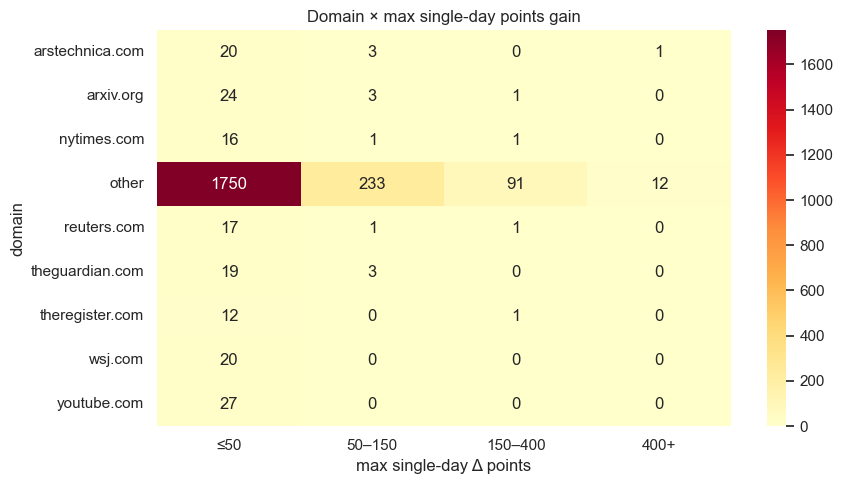

Δ points vs rank climb: Spearman rho=0.087, p=1.707e-09


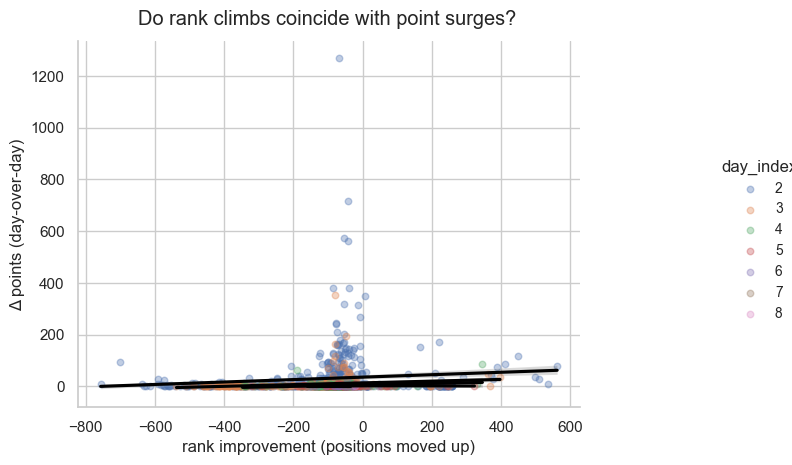

In [6]:
domain_top = (
    lifecycle["domain"].value_counts().head(8).index.tolist()
    if lifecycle["domain"].nunique() > 8
    else lifecycle["domain"].unique().tolist()
)
lifecycle["domain_top"] = lifecycle["domain"].where(
    lifecycle["domain"].isin(domain_top), other="other"
)
lifecycle["surge_bucket"] = pd.cut(
    lifecycle["max_single_day_gain"],
    bins=[-np.inf, 50, 150, 400, np.inf],
    labels=["≤50", "50–150", "150–400", "400+"],
)

ct = pd.crosstab(lifecycle["domain_top"], lifecycle["surge_bucket"])
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Domain × max single-day points gain")
ax.set_xlabel("max single-day Δ points")
ax.set_ylabel("domain")
plt.tight_layout()
plt.show()

trans_plot = transitions.dropna(subset=["points_delta", "rank_improvement"])
rho_pts_rank, p_pts_rank = stats.spearmanr(trans_plot["points_delta"], trans_plot["rank_improvement"])
print(f"Δ points vs rank climb: Spearman rho={rho_pts_rank:.3f}, p={p_pts_rank:.4g}")

g_lm = sns.lmplot(
    data=trans_plot.sample(min(1200, len(trans_plot)), random_state=7),
    x="rank_improvement",
    y="points_delta",
    hue="day_index",
    height=4.5,
    aspect=1.35,
    scatter_kws={"alpha": 0.35, "s": 22},
    line_kws={"color": "black"},
    legend=True,
)
g_lm.set_axis_labels("rank improvement (positions moved up)", "Δ points (day-over-day)")
g_lm.fig.suptitle("Do rank climbs coincide with point surges?", y=1.03)
g_lm._legend.set_bbox_to_anchor((1.02, 0.5))
g_lm._legend.set_loc("center left")
plt.show()

In [7]:
big_surge = transitions.loc[transitions["points_delta"] >= 400]
surge_by_day = (
    transitions.groupby("snapshot_date")
    .agg(
        transitions=("article_id", "count"),
        median_gain=("points_delta", "median"),
        big_surges=("points_delta", lambda s: (s >= 400).sum()),
    )
    .reset_index()
)

print("=== Virality summary ===")
print(f"Daily snapshots: {panel['snapshot_date'].nunique()} days, {len(articles):,} unique articles in entity table")
print(f"Articles tracked 2+ days: {(days_on_page >= 2).sum():,} ({(days_on_page >= 2).mean() * 100:.1f}% of seen stories)")
print(f"Day-over-day transitions: {len(transitions):,}")
print(f"Transitions with ≥400 point gain: {len(big_surge):,} ({len(big_surge) / len(transitions) * 100:.2f}%)")
print(f"Median Δ points on transition days: {transitions['points_delta'].median():.0f}")
print(f"Median rank improvement: {transitions['rank_improvement'].median():.0f} positions")
print()
print("Busiest surge days (≥400 pt jumps):")
print(surge_by_day.sort_values("big_surges", ascending=False).head(5).to_string(index=False))
print()
print("Biggest single-day surge:")
row = transitions.loc[transitions["points_delta"].idxmax()]
print(
    f"  {row['title'][:80]}\n"
    f"  +{row['points_delta']:.0f} points on {row['snapshot_date'].date()}, "
    f"rank {row['rank']:.0f}"
)
print()
print("Strongest cumulative gainer:")
best = lifecycle.loc[lifecycle["total_points_gain"].idxmax()]
print(
    f"  {best['title'][:80]}\n"
    f"  +{best['total_points_gain']:.0f} points over {best['days_seen']} days "
    f"(peak rank #{best['best_rank']:.0f})"
)
print()
print(
    "Takeaway: virality shows up as sharp day-over-day point jumps (often 400+) "
    "while rank can lag — stories may accumulate score deep on the extended front page "
    "before climbing. Multi-day persistence (2–5 days) separates flash spikes from sustained buzz."
)

=== Virality summary ===
Daily snapshots: 19 days, 3,258 unique articles in entity table
Articles tracked 2+ days: 2,261 (69.4% of seen stories)
Day-over-day transitions: 4,764
Transitions with ≥400 point gain: 13 (0.27%)
Median Δ points on transition days: 2
Median rank improvement: -85 positions

Busiest surge days (≥400 pt jumps):
snapshot_date  transitions  median_gain  big_surges
   2026-06-03          306          2.0           2
   2026-06-07          261          1.0           2
   2026-05-29          284          1.5           2
   2026-06-05          239          4.0           2
   2026-06-09          179          3.0           1

Biggest single-day surge:
  S&P 500 rejects SpaceX, also blocking entry for OpenAI and Anthropic
  +1270 points on 2026-06-07, rank 73

Strongest cumulative gainer:
  S&P 500 rejects SpaceX, also blocking entry for OpenAI and Anthropic
  +1337 points over 4 days (peak rank #5)

Takeaway: virality shows up as sharp day-over-day point jumps (often 400